# EC2 transport measurements

The tables and plots below are built directly from the CSV files in `results/`.

For latency, I used the symmetric path producer -> sender -> receiver -> relay -> sender -> receiver -> consumer. The first and last timestamps are both taken on TX. Reported values are the complete RTT divided by two, so they are one-way estimates rather than direct one-way measurements.

The loss runs use 250k messages/s and record 3,000,000 messages after a 100,000-message warm-up. I ran each case twice with the same deterministic sender-side loss pattern in both directions. I did not use the `tc netem` runs because adding the qdisc changed throughput even at 0% loss. Fan-out has delivery results only because its producer and consumers are timed by different host clocks.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd()
if not (root / "results").exists():
    root = root.parent
report_dir = root / "results"
runs = pd.read_csv(report_dir / "loss_matrix_runs.csv")
loss = pd.read_csv(report_dir / "loss_matrix_summary.csv")
saturation = pd.read_csv(report_dir / "saturation_summary.csv")
fanout = pd.read_csv(report_dir / "fanout_summary.csv")
oneway = pd.read_csv(report_dir / "oneway_throughput_runs.csv")
oneway_summary = pd.read_csv(report_dir / "oneway_throughput_summary.csv")


## Plain one-way throughput

For this test, the producer and sender run on TX and the receiver and consumer run on RX. There is one receiver, FEC is off, and no loss is injected. I count a run only when all 3,000,000 measured messages arrive, the consumer reports no drops, the sender never laps its ring, and the receiver publishes every message. Cross-host latency is not used here.

With the FEC-off fast path and a 1,048,576-slot ring, both 1.25M-message/s runs delivered the full finite burst. Both 1.375M runs failed. The sender itself processed about 0.82-0.84M messages/s, which means the large ring buffered the burst; it did not make 1.25M messages/s sustainable.


In [2]:
oneway_summary


,implementation,ring_slots,ring_memory_mib,highest_repeatable_exact_finite_rate,first_repeatable_failed_rate,observed_sender_rate,classification
0,baseline,65536,40,800000.0,1000000,NaN,small ring exposes sustained drain limit
1,baseline,1048576,640,1000000.0,1250000,NaN,burst-buffer improvement
2,fast_path,65536,40,NaN,1000000,848750-854578,small ring still below 1M
3,fast_path,1048576,640,1250000.0,1375000,818975-829348,burst-buffer improvement; not sustained 1.25M


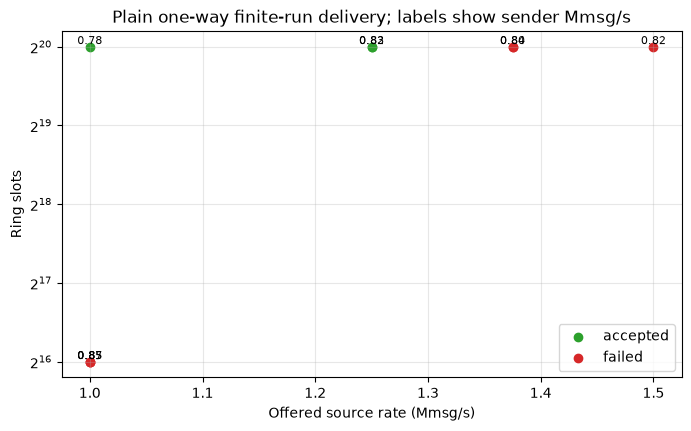

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_runs = oneway[oneway["phase"].eq("fast_path")]
accepted = plot_runs[plot_runs["accepted"]]
failed = plot_runs[~plot_runs["accepted"]]
ax.scatter(accepted["offered_rate"] / 1_000_000, accepted["ring_slots"], label="accepted", color="tab:green")
ax.scatter(failed["offered_rate"] / 1_000_000, failed["ring_slots"], label="failed", color="tab:red")
for _, row in plot_runs.dropna(subset=["sender_effective_rate"]).iterrows():
    rate_m = row["sender_effective_rate"] / 1_000_000
    ax.text(row["offered_rate"] / 1_000_000, row["ring_slots"], f"{rate_m:.2f}", fontsize=8, ha="center", va="bottom")
ax.set_yscale("log", base=2)
ax.set_xlabel("Offered source rate (Mmsg/s)")
ax.set_ylabel("Ring slots")
ax.set_title("Plain one-way finite-run delivery; labels show sender Mmsg/s")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()


## Loss matrix

Each table value is the median of two runs. The CSV also keeps the minimum and maximum. I show the delivered count next to the latency percentiles because a run that loses samples can otherwise appear to have a better tail.


In [4]:
loss[[
    "loss_pct_per_direction", "fec_k", "delivered_median",
    "end_to_end_missing_pct_median", "p50_us_median", "p99_us_median",
    "p999_us_median", "p9999_us_median"
]].style.format({
    "end_to_end_missing_pct_median": "{:.6f}",
    "p50_us_median": "{:.3f}", "p99_us_median": "{:.3f}",
    "p999_us_median": "{:.3f}", "p9999_us_median": "{:.3f}",
})


,loss_pct_per_direction,fec_k,delivered_median,end_to_end_missing_pct_median,p50_us_median,p99_us_median,p999_us_median,p9999_us_median
0,0.000000,0,3000000.000000,0.000000,53.593,85.641,140.066,164.256
1,0.000000,8,3000000.000000,0.000000,61.776,120.265,170.469,193.999
2,0.010000,0,2999366.000000,0.021133,54.981,109.007,172.093,199.736
3,0.010000,8,3000000.000000,0.000000,57.008,102.757,161.659,184.690
4,0.100000,0,2993759.000000,0.208033,54.052,99.026,169.721,201.674
5,0.100000,8,2999960.500000,0.001316,57.108,139.454,186.324,226.716
6,1.000000,0,2937685.000000,2.077167,53.331,101.169,169.138,193.288
7,1.000000,8,2995096.000000,0.163467,59.773,108.537,171.988,206.828


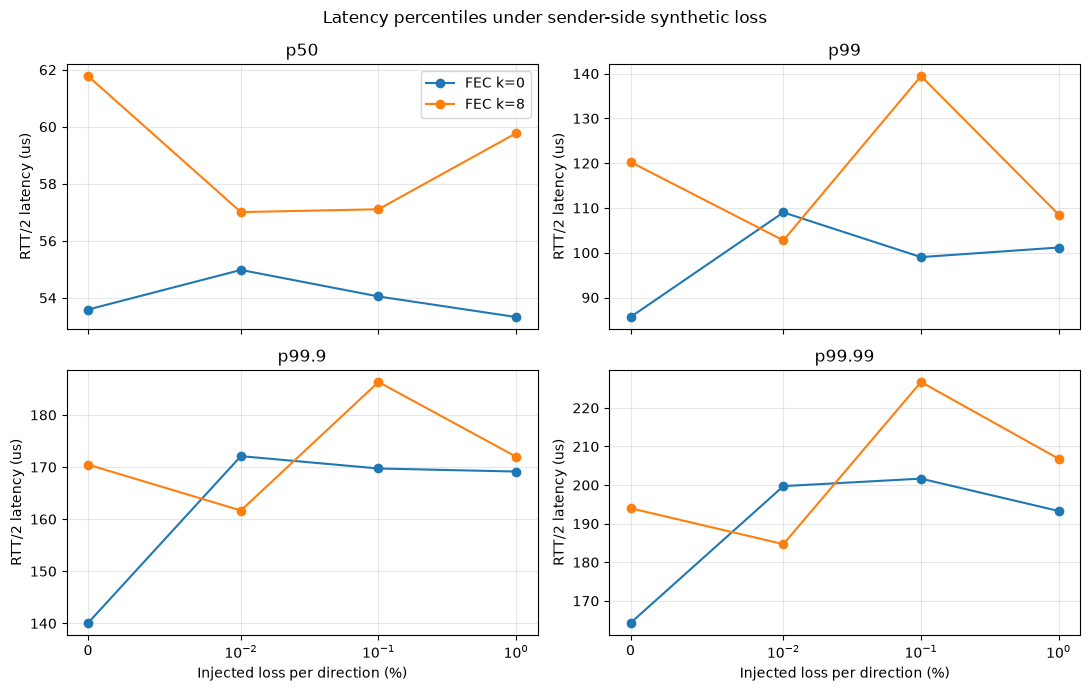

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, metric, title in zip(
    axes.flat,
    ["p50_us_median", "p99_us_median", "p999_us_median", "p9999_us_median"],
    ["p50", "p99", "p99.9", "p99.99"],
):
    for fec_k, group in loss.groupby("fec_k"):
        ax.plot(group["loss_pct_per_direction"], group[metric], marker="o", label=f"FEC k={fec_k}")
    ax.set_xscale("symlog", linthresh=0.01)
    ax.set_title(title)
    ax.set_ylabel("RTT/2 latency (us)")
    ax.grid(True, alpha=0.3)
axes[1, 0].set_xlabel("Injected loss per direction (%)")
axes[1, 1].set_xlabel("Injected loss per direction (%)")
axes[0, 0].legend()
fig.suptitle("Latency percentiles under sender-side synthetic loss")
fig.tight_layout()
plt.show()


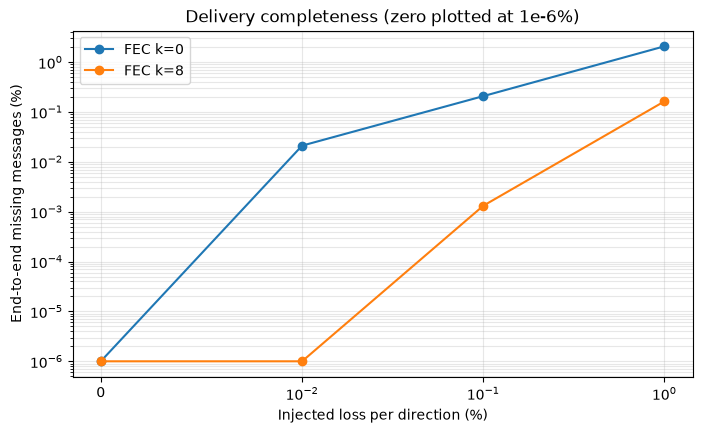

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for fec_k, group in loss.groupby("fec_k"):
    plotted = group["end_to_end_missing_pct_median"].clip(lower=1e-6)
    ax.plot(group["loss_pct_per_direction"], plotted, marker="o", label=f"FEC k={fec_k}")
ax.set_xscale("symlog", linthresh=0.01)
ax.set_yscale("log")
ax.set_xlabel("Injected loss per direction (%)")
ax.set_ylabel("End-to-end missing messages (%)")
ax.set_title("Delivery completeness (zero plotted at 1e-6%)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()


At 0.01% loss, FEC recovered every measured message. This is also the only loss setting where all of its median latency values were not worse. The p99 value is 5.7% lower, but that difference is within the run-to-run variation seen elsewhere. Two runs with one fixed loss pattern are not enough to call it a latency improvement. At 0.1% and 1% loss, FEC greatly reduced missing messages but made every reported median percentile slower. It was also slower at every percentile with no loss.

Loss is applied in the sender before `sendmmsg`. A dropped datagram therefore uses no kernel or NIC transmit work, unlike a packet lost in flight. This makes the FEC cost in these tests look somewhat better than it would with real network loss. Throughput is also lower with FEC: k=8 is exact at 250k messages/s but laps at 400k and 500k, while the FEC-off path is exact at 725k messages/s.


## Symmetric RTT/2 saturation

A passing run has exact delivery, no sender or relay laps, and no receiver rejects. I kept the first clean-disk failure in the table because its counters show where the pipeline breaks.


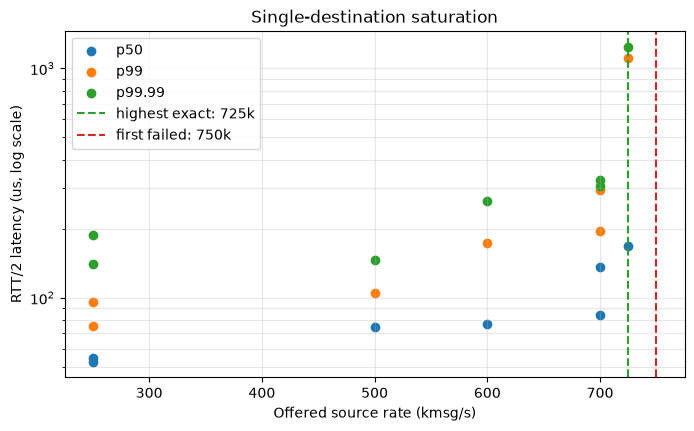

In [7]:
accepted = saturation[saturation["status"] == "accepted"]
fig, ax = plt.subplots(figsize=(8, 4.5))
for metric, label in [("p50_us", "p50"), ("p99_us", "p99"), ("p9999_us", "p99.99")]:
    ax.scatter(accepted["offered_rate_msg_s"] / 1000, accepted[metric], label=label)
ax.axvline(725, color="tab:green", linestyle="--", label="highest exact: 725k")
ax.axvline(750, color="tab:red", linestyle="--", label="first failed: 750k")
ax.set_yscale("log")
ax.set_xlabel("Offered source rate (kmsg/s)")
ax.set_ylabel("RTT/2 latency (us, log scale)")
ax.set_title("Single-destination saturation")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()


The 725k run delivers every message; the 750k run fails when the forward sender laps its input ring. Tail latency is already above 1 ms at 725k, so a latency-sensitive deployment should operate below that rate.

## Fan-out

These fan-out runs measure delivery only. One and two destinations pass at a 275k source rate. Three destinations pass at 250k but the sender does not finish at 275k. A one-destination control also fails at the equivalent aggregate rate of 825k datagrams/s, so the sequential destination loop is not enough by itself to explain the limit.


In [8]:
fanout


,run,receivers,source_rate_msg_s,offered_datagrams_s,status,measured_deliveries,reason
0,fanout/control1_275k,1,275000,275000,accepted,3000000.0,exact delivery; sender lapped=0
1,fanout/fanout2_275k,2,275000,550000,accepted,6000000.0,exact delivery to both receivers; sender lapped=0
2,fanout/three_receivers_250k,3,250000,750000,accepted,9000000.0,exact delivery to all three receivers; sender ...
3,fanout/fanout3_275k,3,275000,825000,rejected,NaN,sender did not exit within 72 s; no counters a...
4,fanout/control1_825k,1,825000,825000,rejected,NaN,sender did not exit within 64 s; no counters a...


## Clock and impairment caveats

Neither Ubuntu host exposed a PHC. I tried faster Amazon Time Sync polling and direct-LAN chrony interleaved mode. Chrony sometimes reported sub-microsecond correction, but independent probes in opposite directions disagreed by several microseconds. I therefore did not subtract timestamps across hosts. A later Amazon Linux 2023 test exposed the ENA PHC with `ena.phc_enable=1`, but its 22.735 us and 28.038 us hardware-error bounds were still too large for these measurements. The final results use RTT/2.

I also tried a filtered root qdisc, netem on the mq leaves, and ingress IFB netem. Each one changed the 500k throughput even at 0% loss. A port-specific iptables loss rule made `sendmmsg` return EPERM. I excluded those runs and used deterministic loss before `sendmmsg` instead. The manifests and tables identify that method. Since dropped datagrams do no kernel or NIC transmit work, this setup understates the cost of FEC compared with real in-flight loss.
